In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow import keras
from skimage.metrics import structural_similarity as ssim
import os
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, Dropout
import cv2
from tqdm import tqdm
import tqdm as notebook_tqdm
import imutils
import pywt

In [4]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from skimage.exposure import equalize_adapthist
from skimage.filters import gaussian as sk_gaussian
from tqdm import tqdm
import psutil
from scipy.ndimage import uniform_filter, gaussian_filter

DIM         = 64
NUM_CLASSES = 2

TRAIN_DIR = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train'
TEST_DIR  = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test'

# ── Load raw data ─────────────────────────────────────────────────────────────
def load_data(data_dir, dim=DIM):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode='int',
        image_size=(dim, dim),
        batch_size=None,
        shuffle=False
    )
    x = np.array([item[0].numpy() for item in ds])
    y = np.array([item[1].numpy() for item in ds])
    return x, y

print('Loading training data...')
x_train_raw, y_train_int = load_data(TRAIN_DIR)
print('Loading test data...')
x_test_raw,  y_test_int  = load_data(TEST_DIR)

n_train, n_test = len(x_train_raw), len(x_test_raw)
print(f'Train: {n_train} | Test: {n_test}')

# Verify class order — Keras sorts alphabetically
class_names = sorted(os.listdir(TRAIN_DIR))
print(f'Class order: {class_names}')  # [NORMAL, PNEUMONIA] -> 0, 1

# ── Grayscale + normalise ─────────────────────────────────────────────────────
def to_gray_norm(images_rgb, N):
    out = np.empty((N, DIM, DIM), dtype=np.float32)
    for i in tqdm(range(N), desc='Grayscale+Norm'):
        gray   = cv2.cvtColor(images_rgb[i].astype(np.uint8),
                               cv2.COLOR_RGB2GRAY)
        out[i] = gray / 255.0
    return out

x_train_gray = to_gray_norm(x_train_raw, n_train)
x_test_gray  = to_gray_norm(x_test_raw,  n_test)
del x_train_raw, x_test_raw

# ── One-hot labels ────────────────────────────────────────────────────────────
y_train = to_categorical(y_train_int, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_int,  num_classes=NUM_CLASSES)

# ── Preprocessing — CLAHE + central crop + smoothing (no segmentation) ────────
def preprocess_xray(img):
    """
    Input : (64, 64) float32 in [0,1] — grayscale, normalised
    Output: (64, 64) float32 in [0,1]
    Steps : CLAHE → fixed central crop → resize → Gaussian smooth → renorm
    """
    # 1. CLAHE
    img = equalize_adapthist(img, clip_limit=0.03).astype(np.float32)
    # 2. Fixed central crop — removes chest wall borders
    h, w  = img.shape
    pad_h = int(h * 0.10)
    pad_w = int(w * 0.08)
    img   = img[pad_h:h-pad_h, pad_w:w-pad_w]
    # 3. Resize back to 64x64
    img = cv2.resize(img, (DIM, DIM), interpolation=cv2.INTER_AREA)
    # 4. Gaussian smoothing
    img = sk_gaussian(img, sigma=0.5).astype(np.float32)
    # 5. Re-normalise
    if img.max() > 1e-8:
        img = img / img.max()
    return img

print('Preprocessing training images...')
x_train_normal = np.zeros((n_train, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_train), desc='Train'):
    x_train_normal[i] = preprocess_xray(x_train_gray[i])

print('Preprocessing test images...')
x_test_normal = np.zeros((n_test, DIM, DIM), dtype=np.float32)
for i in tqdm(range(n_test), desc='Test'):
    x_test_normal[i] = preprocess_xray(x_test_gray[i])

del x_train_gray, x_test_gray


def apply_smooth_region_filter(image, window=20):
    """
    Suppresses high-contrast edge regions (ribs) and preserves
    smooth regions (consolidation opacity).

    Parameters
    ----------
    image  : (H, W) float32 in [0,1]
    window : int — neighbourhood size (5-7 at 64×64, 9-11 at 128×128)

    Returns
    -------
    filtered : (H, W) float32 in [0,1] — edge-suppressed image
    """
    mean_sq   = uniform_filter(image**2, size=window)
    sq_mean   = uniform_filter(image,    size=window)**2
    local_std = np.sqrt(np.clip(mean_sq - sq_mean, 0, None)).astype(np.float32)

    # Smooth mask — inverse of normalised local std
    s_rng = local_std.max() - local_std.min()
    local_std_norm  = (local_std - local_std.min()) / (s_rng + 1e-8)
    smooth_mask     = gaussian_filter(1.0 - local_std_norm, sigma=1.0)

    # Apply and renormalise
    filtered = image * smooth_mask
    f_rng    = filtered.max() - filtered.min()
    filtered = (filtered - filtered.min()) / (f_rng + 1e-8)

    return filtered.astype(np.float32)


x_train = np.zeros((n_train, DIM, DIM), dtype=np.float32)
x_test = np.zeros((n_test, DIM, DIM), dtype=np.float32)

for i, img in enumerate(x_train_normal):
    x_train[i] = apply_smooth_region_filter(img)

for i, img in enumerate(x_test_normal):
    x_test[i] = apply_smooth_region_filter(img)

del x_train_normal, x_test_normal


# ── Verify class split ────────────────────────────────────────────────────────
N_NORMAL    = int(np.sum(y_train_int == 0))
N_PNEUMONIA = int(np.sum(y_train_int == 1))
print(f'\nNormal    : {N_NORMAL}  (idx 0 to {N_NORMAL-1})')
print(f'Pneumonia : {N_PNEUMONIA}  (idx {N_NORMAL} to {n_train-1})')
print(f'x_train   : {x_train.shape}')
print(f'x_test    : {x_test.shape}')

ram = psutil.virtual_memory()
print(f'RAM available: {ram.available/1e9:.1f} GB')


Loading training data...
Found 5216 files belonging to 2 classes.


2026-04-22 22:30:28.497512: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Loading test data...
Found 624 files belonging to 2 classes.


2026-04-22 22:30:35.782370: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-22 22:30:37.050838: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Train: 5216 | Test: 624
Class order: ['NORMAL', 'PNEUMONIA']


...

Preprocessing training images...


Train: 100%|██████████| 5216/5216 [00:12<00:00, 415.71it/s]


Preprocessing test images...


Test: 100%|██████████| 624/624 [00:01<00:00, 424.15it/s]



Normal    : 1341  (idx 0 to 1340)
Pneumonia : 3875  (idx 1341 to 5215)
x_train   : (5216, 64, 64)
x_test    : (624, 64, 64)
RAM available: 11.7 GB


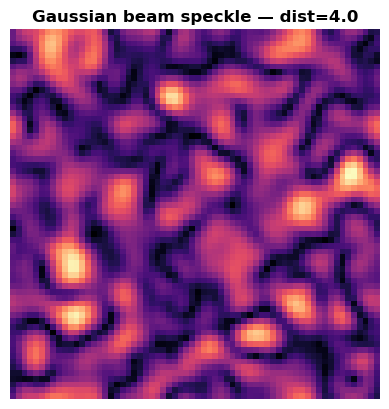

Dataset shape: (10000, 64, 64)
Range: [0.000, 1.000]


In [5]:
def generate_gaussian_speckle(dist, DIM=64):
    """
    Replaces Baurzhan's LG beam speckle with a Gaussian beam speckle.
    
    The Gaussian beam profile emphasises low frequencies — 
    matching the spatial scale of consolidation opacity.
    
    Baurzhan used: R2/dist * exp(-R2/dist)  — LG profile (ring-shaped)
    We use:        exp(-R2/sigma²)           — Gaussian profile (blob-shaped)
    
    The LG profile has a dark centre (DC suppression) — wrong for opacity.
    The Gaussian profile has a bright centre (DC preserved) — correct for opacity.
    
    Parameters
    ----------
    DIM        : int   — image dimension
    sigma_beam : float — Gaussian beam width in pixel coordinates
                         larger sigma → lower frequency content
                         20-40 at 128×128 matches consolidation scale
    
    Returns
    -------
    speckle : (DIM, DIM) float32 — ground truth speckle
    """
    x       = np.linspace(-10, 10, DIM)
    X, Y    = np.meshgrid(x, x)
    R2      = X**2 + Y**2

    # Gaussian beam profile — bright centre, low frequency
    # Controls the spatial scale of the generated speckle
    beam    = np.exp(-R2 / dist)

    # Random phase — adds diversity
    RandP   = np.random.uniform(size=(DIM, DIM))

    # Generate speckle
    speckle = np.abs(np.fft.fft2(beam * np.exp(1j * 2 * np.pi * RandP)))
    
    # Normalise
    s_min   = speckle.min()
    s_rng   = speckle.max() - s_min
    speckle = (speckle - s_min) / (s_rng + 1e-8)

    return speckle.astype(np.float32)


# Generate dataset of ground truth speckles
np.random.seed(101)

imax = 10000
DIM  = 64
dist = 4.0   # optimal dist for consolidation frequency scale

datasets = np.zeros((imax, DIM, DIM), dtype=np.float32)

for j in range(imax):
    datasets[j] = generate_gaussian_speckle(dist, DIM=DIM)

plt.imshow(datasets[50], cmap='magma')
plt.title(f'Gaussian beam speckle — dist={dist}', fontweight='bold')
plt.axis('off')
plt.show()

print(f'Dataset shape: {datasets.shape}')  # (10000, 128, 128)
print(f'Range: [{datasets.min():.3f}, {datasets.max():.3f}]')

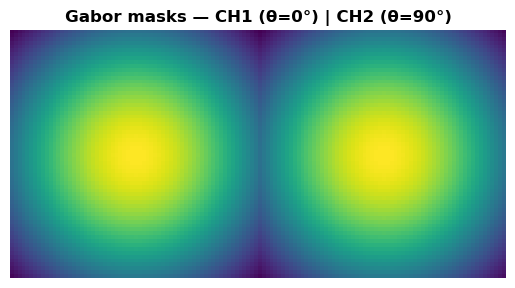

Encoding Gaussian speckles...
Gaussian speckles shape  : (10000, 64, 64)
Encoded speckles shape   : (10000, 64, 128)
Encoded speckles range   : [-1.000, 1.000]


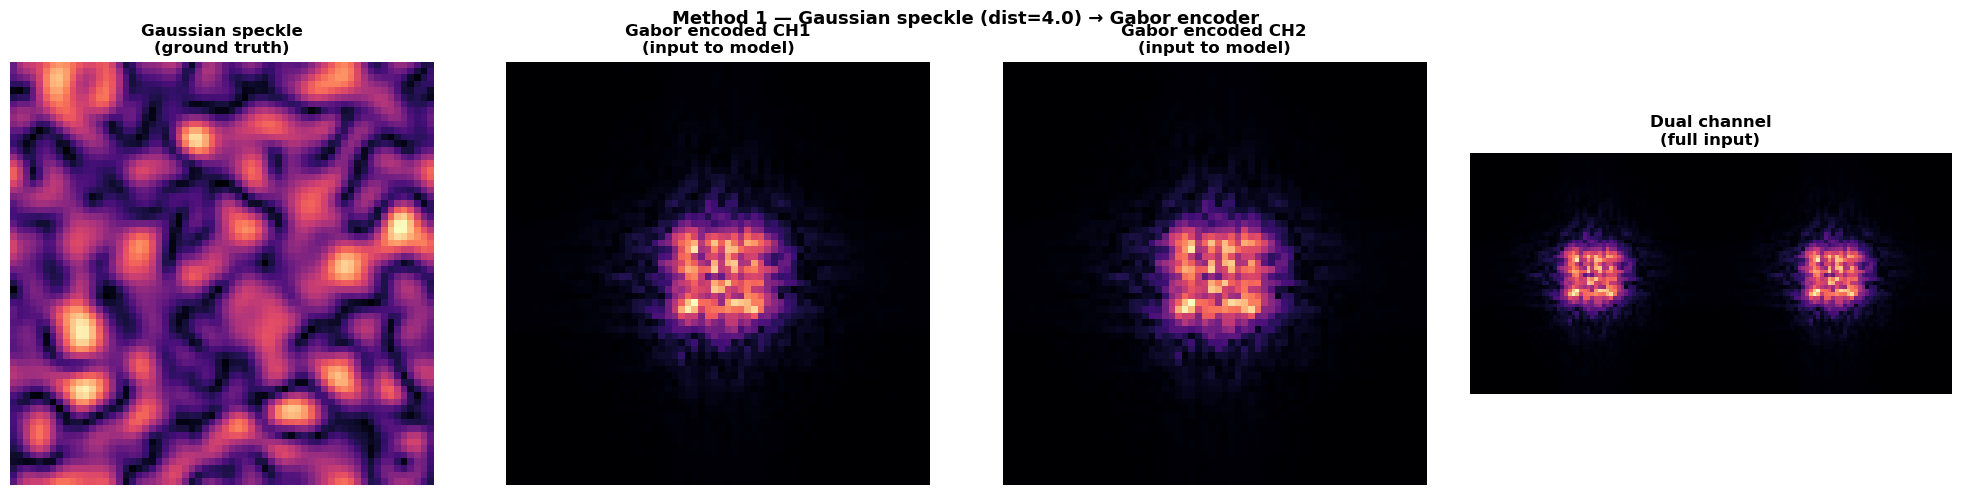

In [6]:
def myfft2(A):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))


def gabor_THIS(A, GM1, GM2):
    """
    Gabor encoder — direct replacement for Baurzhan's vort_THIS.

    Takes a batch of images and applies:
    1. Phase encode: exp(i * image * pi/2)  — same as Baurzhan
    2. Multiply by Lens
    3. FFT (myfft2)
    4. Multiply by Gabor mask in Fourier plane — replaces vortex mask
    5. Take magnitude
    6. Normalise to [-1, 1]
    7. Concatenate dual channel

    Can be applied to both:
    - Gaussian beam speckles (Method 1 training)
    - Real chest X-ray images (Method 2 training + inference)

    Parameters
    ----------
    A   : (N, H, W) float32 — batch of images in [0,1]
    GM1 : (H, W) float64   — Gabor Fourier mask channel 1
    GM2 : (H, W) float64   — Gabor Fourier mask channel 2

    Returns
    -------
    out : (N, H, W*2) float32 — dual channel Gabor encoded, normalised to [-1,1]
    """
    length = A.shape[0]
    out    = np.zeros((length, A.shape[1], A.shape[2] * 2), dtype=np.float32)

    for i in range(length):
        phase = np.exp(1j * A[i].astype(np.float64) * np.pi / 2)

        A1 = np.abs(myfft2(phase * Lens) * GM1).astype(np.float32)
        A2 = np.abs(myfft2(phase * Lens) * GM2).astype(np.float32)

        A1 = (A1 - np.amin(A1)) / (np.amax(A1 - np.amin(A1)) + 1e-8) * 2 - 1
        A2 = (A2 - np.amin(A2)) / (np.amax(A2 - np.amin(A2)) + 1e-8) * 2 - 1

        out[i] = np.hstack((A1, A2))

    return out


def make_gabor_mask(DIM=64, omega_0=0.07, theta=0, sigma_f=0.5):
    """
    Gabor mask in the Fourier plane.
    Gaussian blob centred at (omega_0, theta) — bandpass filter.

    Parameters
    ----------
    DIM     : int   — image dimension
    omega_0 : float — centre frequency in cycles/pixel
    theta   : float — orientation in radians
    sigma_f : float — bandwidth

    Returns
    -------
    mask : (DIM, DIM) float64 in [0,1]
    """
    freqs = np.fft.fftshift(np.fft.fftfreq(DIM))
    U, V  = np.meshgrid(freqs, freqs)

    u0 = omega_0 * np.cos(theta)
    v0 = omega_0 * np.sin(theta)

    mask_pos = np.exp(-((U - u0)**2 + (V - v0)**2) / (2 * sigma_f**2))
    mask_neg = np.exp(-((U + u0)**2 + (V + v0)**2) / (2 * sigma_f**2))

    mask = mask_pos + mask_neg
    mask = mask / mask.max()

    return mask.astype(np.float64)


# ── Coordinates + Lens — same as Baurzhan ─────────────────────────────────────
DIM     = 64
xmax    = 10
dx      = 2 * xmax / DIM

x       = np.linspace(-xmax, xmax - dx, DIM)
X, Y    = np.meshgrid(x, x)
R2      = X**2 + Y**2
T       = np.arctan2(Y, X)

flambda = 80
Lens    = np.exp(-1j * R2 / (flambda / 10))

# ── Gabor masks ───────────────────────────────────────────────────────────────
GM1 = make_gabor_mask(DIM, omega_0=0.07, theta=0,       sigma_f=0.5)
GM2 = make_gabor_mask(DIM, omega_0=0.07, theta=np.pi/2, sigma_f=0.5)

plt.imshow(np.hstack((GM1, GM2)), cmap='viridis')
plt.title('Gabor masks — CH1 (θ=0°) | CH2 (θ=90°)', fontweight='bold')
plt.axis('off')
plt.show()

# ── Encode Gaussian speckles — Method 1 ──────────────────────────────────────
# datasets shape: (10000, 128, 128) — single dist=4.0
print('Encoding Gaussian speckles...')
encoded_speckles = gabor_THIS(datasets, GM1, GM2)   # (10000, 128, 256)

print(f'Gaussian speckles shape  : {datasets.shape}')
print(f'Encoded speckles shape   : {encoded_speckles.shape}')
print(f'Encoded speckles range   : [{encoded_speckles.min():.3f}, '
      f'{encoded_speckles.max():.3f}]')

# ── Visual check ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(datasets[50],                      cmap='magma')
axes[0].set_title('Gaussian speckle\n(ground truth)', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(encoded_speckles[50, :, :DIM],     cmap='magma')
axes[1].set_title('Gabor encoded CH1\n(input to model)', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(encoded_speckles[50, :, DIM:],     cmap='magma')
axes[2].set_title('Gabor encoded CH2\n(input to model)', fontweight='bold')
axes[2].axis('off')

axes[3].imshow(encoded_speckles[50],               cmap='magma')
axes[3].set_title('Dual channel\n(full input)', fontweight='bold')
axes[3].axis('off')

plt.suptitle(f'Method 1 — Gaussian speckle (dist={dist}) → Gabor encoder',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

DIM = 64

# ── Method 1 — Gaussian speckles ─────────────────────────────────────────────
X_train_gauss = encoded_speckles.reshape(len(encoded_speckles), -1).astype(np.float32)
Y_train_gauss = datasets.reshape(len(datasets), -1).astype(np.float32)

print(f'Method 1 — Gaussian speckles:')
print(f'X_train : {X_train_gauss.shape}')   # (10000, 32768)
print(f'Y_train : {Y_train_gauss.shape}')   # (10000, 16384)

# ── Build model ───────────────────────────────────────────────────────────────
model_gauss = Sequential([
    Dense(DIM**2, input_dim=DIM**2 * 2,
          activation='linear', use_bias=False)
], name='recon_gauss')
model_gauss.compile(loss='mse', optimizer=Adam(), metrics=['mae'])
model_gauss.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
history_gauss = model_gauss.fit(
    X_train_gauss, Y_train_gauss,
    epochs=5000,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

SAVE_GAUSS = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/recon_gauss.keras'
model_gauss.save(SAVE_GAUSS)
print(f'Model 1 saved to:\n{SAVE_GAUSS}')

In [ ]:
CUSTOM_OBJECTS = {
            # 1. Metrics (Likely Source of Error)
            'keras.metrics.MSE': tf.keras.metrics.MeanSquaredError(),
            'MSE': tf.keras.metrics.MeanSquaredError(),
            'mse': tf.keras.metrics.MeanSquaredError(),
            
            # 2. Loss Functions (Possible Source of Error)
            'mean_squared_error': tf.keras.losses.MeanSquaredError(),
            
            # 3. Optimizers (Needed if you want to resume training, though not needed for prediction)
            'rmsprop': tf.keras.optimizers.RMSprop() 
        }


model_path = f'/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/Reconstruction Models/recon_gauss.keras'
reconstruction_model = load_model(model_path, custom_objects=CUSTOM_OBJECTS)

recon_train = reconstruction_model.predict(gabor_THIS(x_train, GM1, GM2).reshape(len(x_train), 2*DIM**2)).reshape(-1, 64, 64)
recon_test = reconstruction_model.predict(gabor_THIS(x_test, GM1, GM2).reshape(len(x_test), 2*DIM**2)).reshape(-1, 64, 64)


In [15]:
idx_healthy = np.where(y_train_int==0)
healthy = recon_train[idx_healthy]

idx_unhealthy = np.where(y_train_int==1)
unhealthy = recon_train[idx_unhealthy]

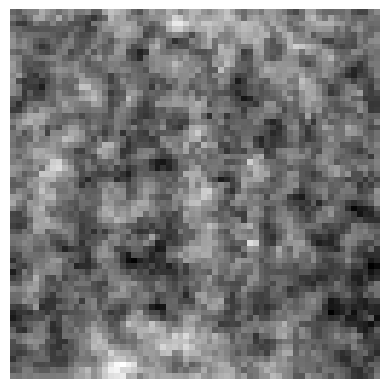

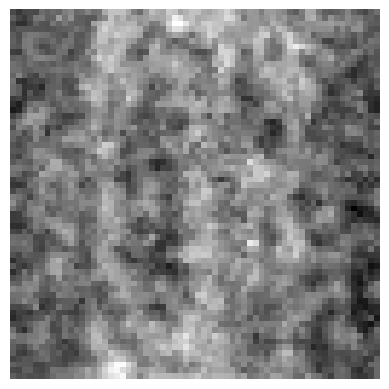

In [20]:
plt.imshow(healthy[3], cmap='gray')
plt.axis('off')
plt.show()

plt.imshow(unhealthy[10], cmap='gray')
plt.axis('off')
plt.show()